In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc, ConfusionMatrixDisplay

In [2]:
# -----------------------------
# 1. LOAD DATASET
# -----------------------------
data = pd.read_csv("C:\\Users\\miran\\OneDrive\\Documents\\AI-Collective-AIC-Team-7\\Amazon_data.csv")
print(data.head())

   Unnamed: 0  Adj Close    Close     High      Low     Open     Volume  \
0           1     8.7125   8.7125   8.8970   8.6865   8.8165   84050000   
1           2     8.7785   8.7785   8.9500   8.6795   8.6860  116210000   
2           3     8.8875   8.8875   8.9875   8.7280   8.8430   93130000   
3           9    11.3575  11.3575  11.9505  11.2945  11.9295  280252000   
4          12     9.3900   9.3900   9.4085   9.2305   9.3495   86128000   

  Company        Date  Target  Score  Comments  \
0  Amazon  2010-12-13       1      7         5   
1  Amazon  2010-12-15       1      8         0   
2  Amazon  2011-02-24       1      5         1   
3  Amazon  2011-10-25       1     16        12   
4  Amazon  2012-01-25      -1      8        13   

                                        Cleaned_Text Sentiment  \
0                  hussman warning awful time invest   Neutral   
1      awful time invest reflection lost opportunity  Negative   
2             amazon prime streaming disrupt netfl

In [3]:
# -----------------------------
# 2. DATA CLEANING
# -----------------------------

# Convert Target: -1 → 0 (DOWN), 1 stays 1 (UP)
data['Target'] = data['Target'].replace(-1, 0)

# Drop rows with missing values
data = data.dropna()

# Convert Date to datetime
data['Date'] = pd.to_datetime(data['Date'])

# Sort by time (for time series)
data = data.sort_values(by='Date')

In [4]:
# -----------------------------
# 3. FEATURE SELECTION
# -----------------------------
# Keeping it simple for baseline

# Our INPUT(X) columns
features = ['Close', 'Volume', 'High', 'Low', 'Open']
X = data[features]

# Our OUTPUT (Y) -> 1 == UP, 0 == DOWN
y = data['Target']

In [5]:
# -----------------------------
# 4. TRAIN-TEST SPLIT - splits dataset
# -----------------------------
# DO NOT shuffle (time series data)

# here we are doing:
  # 80% of dataset for ML model training
  # 20% of dataset for ML model testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [6]:
# -----------------------------
# 5. SCALE FEATURES
# -----------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



In [7]:
# -----------------------------
# 6. TRAIN MODEL - learns patterns from part of the dataset (80%)
# -----------------------------

# supposedly ML learns better with precentages so i tried converting them with this
#
# data['return'] = data['close'].pctchange()
# data['hig2low change'] = (data['High'] - data['Low']) / data['Open']
# data['open2close change'] = (data['Close'] - data['Open']) / data['Open']
# data['volume change'] = data['Volume'].pct_change()

model = RandomForestClassifier()

# Only trained on training data
model.fit(X_train_scaled, y_train)

print("\nModel training complete!")


Model training complete!


In [8]:
# -----------------------------
# 7. TEST MODEL - evaluates on unseen part of the dataset (20%)
# -----------------------------
# Where predictions are tested
  # Runs predictions on unseen data
y_pred = model.predict(X_test_scaled)

# This accuracy checks how well the model works on new unseen data (the testing data)
accuracy = accuracy_score(y_test, y_pred)

print("\nModel Evaluation:")
print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Model Evaluation:
Accuracy: 0.9474393530997305

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.95      0.95       373
           1       0.95      0.94      0.95       369

    accuracy                           0.95       742
   macro avg       0.95      0.95      0.95       742
weighted avg       0.95      0.95      0.95       742


Confusion Matrix:
[[356  17]
 [ 22 347]]


In [9]:
# -----------------------------
# 8. PREDICTION FUNCTION (FOR FRONTEND) - used on new data (outside dataset)
# -----------------------------

def predict_stock(input_data):

    input_df = pd.DataFrame([input_data])

    # Scale using SAME scaler
    input_scaled = scaler.transform(input_df)

    # UP/DOWN Prediction
    prediction = model.predict(input_scaled)[0]
    probabilities = model.predict_proba(input_scaled)[0]

    # Frontend would display this part later
    return {
        "prediction": "UP" if prediction == 1 else "DOWN",
        "confidence": max(probabilities)
    }

In [10]:
# -----------------------------
# 9. TEST PREDICTION FUNCTION
# -----------------------------
sample_input = {
    'Close': 150,
    'Volume': 1000000,
    'High': 152,
    'Low': 148,
    'Open': 149
}

result = predict_stock(sample_input)

print("\nSample Prediction:")
print(result)


Sample Prediction:
{'prediction': 'UP', 'confidence': np.float64(0.77)}


c:\Users\miran\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\miran\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


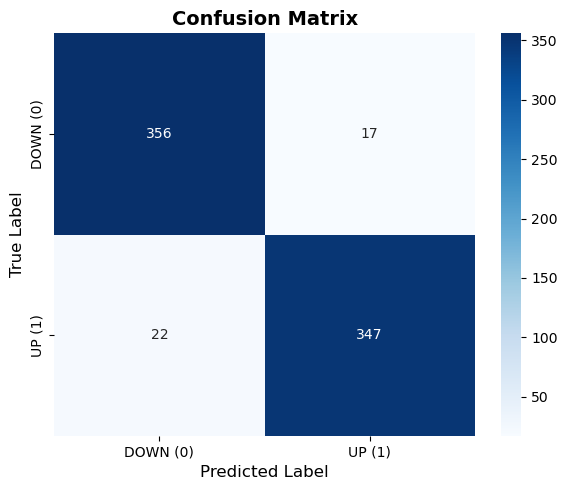

In [11]:
# 7B - Visual Outputs - Confusion Matrix and ROC-AUC Curve - Danny
# Confusion Matrix Heatmap 
cm = confusion_matrix(y_test, y_pred)

fig_cm, ax_cm = plt.subplots(figsize=(6, 5))

# Color-coded confusion matrix with labeled axes (DOWN/UP)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['DOWN (0)', 'UP (1)'],
    yticklabels=['DOWN (0)', 'UP (1)'],
    ax=ax_cm
)
ax_cm.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
ax_cm.set_xlabel('Predicted Label', fontsize=12)
ax_cm.set_ylabel('True Label', fontsize=12)
plt.tight_layout()

# Saves cm as PNG
fig_cm.savefig("RFConfusionMatrix.png", dpi=150)
plt.show()


 AUC Score: 0.9805


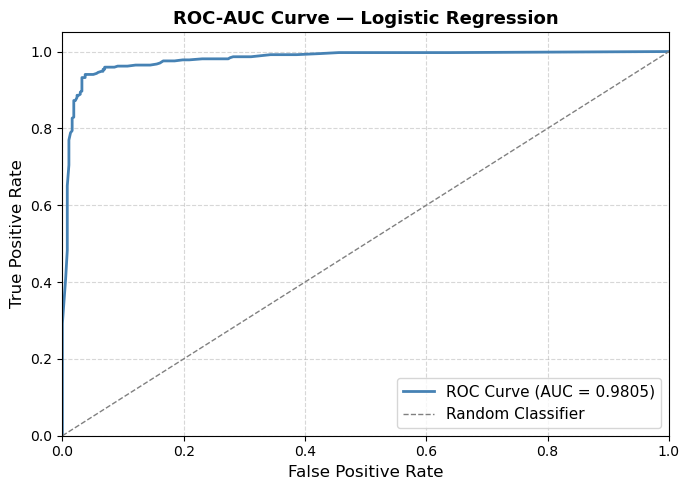

In [12]:
# ROC-AUC Curve
# predict_proba gives probability scores: we use the prob of class 1 (UP)
  # pulls the probability of UP (class 1), which is what ROC needs
# dashed diagonal line on the ROC curve represents a random classifier (AUC = 0.5)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Computes FPR/TPR across all thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Single AUC score shown in the legend
roc_auc = auc(fpr, tpr)

fig_roc, ax_roc = plt.subplots(figsize=(7, 5))
ax_roc.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax_roc.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
ax_roc.set_xlim([0.0, 1.0])
ax_roc.set_ylim([0.0, 1.05])
ax_roc.set_xlabel('False Positive Rate', fontsize=12)
ax_roc.set_ylabel('True Positive Rate', fontsize=12)
ax_roc.set_title('ROC-AUC Curve — Logistic Regression', fontsize=13, fontweight='bold')
ax_roc.legend(loc='lower right', fontsize=11)
ax_roc.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Save as PNG
fig_roc.savefig("RF_ROC_AUC_Curve.png", dpi=150)
print(f"\n AUC Score: {roc_auc:.4f}")
plt.show()
